# **Imports and Functions**

In [1]:
!pip install rdkit-pypi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 36.2 MB/s eta 0:00:00


In [2]:
# Imports
import os
import tempfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from google.colab import files

In [ ]:
# Functions for visualizing chemical space from: https://practicalcheminformatics.blogspot.com/2019/11/visualizing-chemical-space.html
sns.set(rc={'figure.figsize': (10, 10)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

def fp_list_from_smiles_list(smiles_list, n_bits=2048):
    fp_list = []
    for smiles in tqdm(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol == None:
            continue
        fp_list.append(fp_as_array(mol, n_bits))
    return fp_list

def fp_as_array(mol,n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    arr = np.zeros((1,), int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# **t-SNE of Chemical Structures of Exisiting Promoieties**

In [ ]:
# Combine various groups together and label their types
# Upload the datasets from the datasets folder
df1 = pd.read_csv('PurchasableFragments.csv')
df1['Type'] = 'Fragment'
df2 = pd.read_csv('UniquePromoietiesOfFDAProdrugs.csv')
df2['Type'] = 'Approved'
df3 = pd.read_csv('InvestigationalProdrugPromoieties.csv')
df3['Type'] = 'Investigational'

df = pd.concat([df1, df2, df3])
df = df.reset_index(drop=True)

In [ ]:
# Actual t-SNE

# Convert to fingerprints and perform a PCA down to 50 components for efficiency
fp_list = fp_list_from_smiles_list(df.SMILES)
pca = PCA(n_components=50)
crds = pca.fit_transform(fp_list)

# Perform t-SNE on the PCA
%time crds_embedded = TSNE(n_components=2).fit_transform(crds)
tsne_df = pd.DataFrame(crds_embedded,columns=["X","Y"])
tsne_df['SMILES'] = df['SMILES']
tsne_df['Type'] = df['Type']
tsne_2 = df.merge(tsne_df, left_on=['SMILES', 'Type'], right_on=['SMILES', 'Type'])

100%|██████████| 2437/2437 [00:00<00:00, 6338.38it/s]


CPU times: user 15.5 s, sys: 149 ms, total: 15.7 s
Wall time: 17.6 s


In [ ]:
dataset = 'FragmentsApprovedInvestigational'

In [ ]:
# Save t-SNE - Note: that t-SNE is not deterministic so exact location of points will vary with repetition
dataset = 'FragmentsApprovedInvestigational_t-SNE.csv'
tsne_2.to_csv('{}_t-SNE.csv'.format(dataset), index = False)

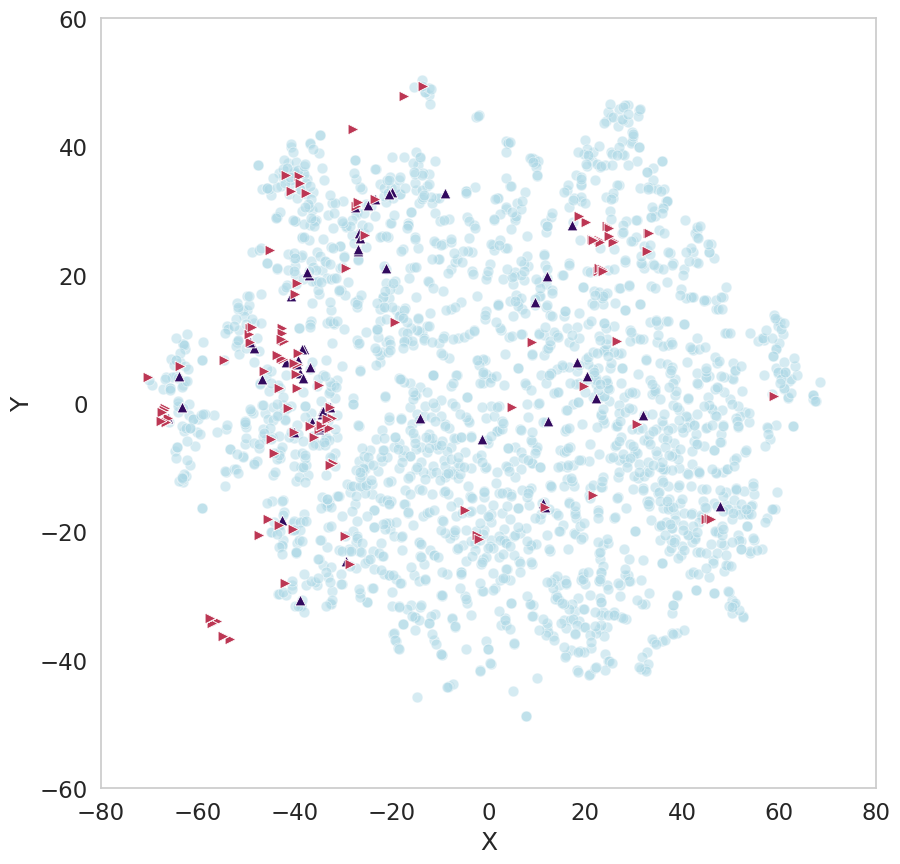

In [ ]:
# Plotting
fig= plt.figure()

# Get datasets
Fragment = tsne_2[tsne_2['Type'] == 'Fragment']
Approved = tsne_2[tsne_2['Type'] == 'Approved']
Investigational = tsne_2[tsne_2['Type'] == 'Investigational']

# Plot
ax = sns.scatterplot(data=Fragment,x="X",y="Y", color='lightblue', s=60, alpha = 0.5)
ax = sns.scatterplot(data=Approved,x="X",y="Y",color='#320a5e', marker = '^', s=60)
ax = sns.scatterplot(data=Investigational,x="X",y="Y",color='#bc3754', marker = '>', s=60)


ax.set_xlim([-80, 80])
ax.set_ylim([-60, 60])

plt.savefig("{}.png".format(dataset), facecolor='white')
files.download("{}.png".format(dataset))

plt.grid()
plt.show()

# **2D plots of molecular complexity**

In [ ]:
# load your file as a dataframe
FDA = pd.read_csv("FDAApprovedProdrugsAndAPIs.csv")
FDA_prodrugs = FDA[['Prodrug_SMILES']]
FDA_APIs = FDA[['API_SMILES']]

Investigational = pd.read_csv("InvestigationalProdrugAPIStructures.csv")
Investigational_prodrugs = Investigational[['Prodrug_SMILES']]
Investigational_APIs = Investigational[['API_SMILES']]

In [ ]:
def get_descriptors_not_normalized(dataframe): # Get RDKit descriptors from dataframe containing SMILES
  # Transform string "SMILES" object into a molecule "object"
  mols = [Chem.MolFromSmiles(s) for s in dataframe.iloc[:,0]]

  # Calculate molecular descriptors (such as molecular weight, sLogP, TPSA, etc..)
  calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
  header = calc.GetDescriptorNames()
  features_df = pd.DataFrame([calc.CalcDescriptors(x) for x in mols], columns=header)
  features_df = features_df.fillna(0)
  features_df = pd.DataFrame(features_df)

  # Return the descriptors
  return(features_df)


# Get Descriptors for each dataframe - Not Normalized
FDA_prodrugs_descriptors = get_descriptors_not_normalized(FDA_prodrugs)
Investigational_prodrugs_descriptors = get_descriptors_not_normalized(Investigational_prodrugs)
FDA_APIs_descriptors = get_descriptors_not_normalized(FDA_APIs)
Investigational_APIs_descriptors = get_descriptors_not_normalized(Investigational_APIs)

# Select just the two descriptors of interest
FDA_APIs_descriptors = FDA_APIs_descriptors[["MolWt", "BertzCT"]]
FDA_prodrugs_descriptors = FDA_prodrugs_descriptors[["MolWt", "BertzCT"]]
Investigational_APIs_descriptors = Investigational_APIs_descriptors[["MolWt", "BertzCT"]]
Investigational_prodrugs_descriptors = Investigational_prodrugs_descriptors[["MolWt", "BertzCT"]]

# Combine Dataframes
FDA_APIs_descriptors = FDA_APIs_descriptors.add_suffix('_API')
FDA_prodrugs_descriptors = FDA_prodrugs_descriptors.add_suffix('_pro')
Investigational_APIs_descriptors = Investigational_APIs_descriptors.add_suffix('_API')
Investigational_prodrugs_descriptors = Investigational_prodrugs_descriptors.add_suffix('_pro')
FDA = pd.concat([FDA_APIs_descriptors, FDA_prodrugs_descriptors], axis = 1)
Investigational = pd.concat([Investigational_APIs_descriptors, Investigational_prodrugs_descriptors], axis = 1)


# Calculate the distance between the points and add as a column
FDA['Distance'] = np.sqrt((FDA['BertzCT_pro'] - FDA['BertzCT_API'])**2 + (FDA['MolWt_pro'] - FDA['MolWt_API'])**2)
Investigational['Distance'] = np.sqrt((Investigational['BertzCT_pro'] - Investigational['BertzCT_API'])**2 + (Investigational['MolWt_pro'] - Investigational['MolWt_API'])**2)

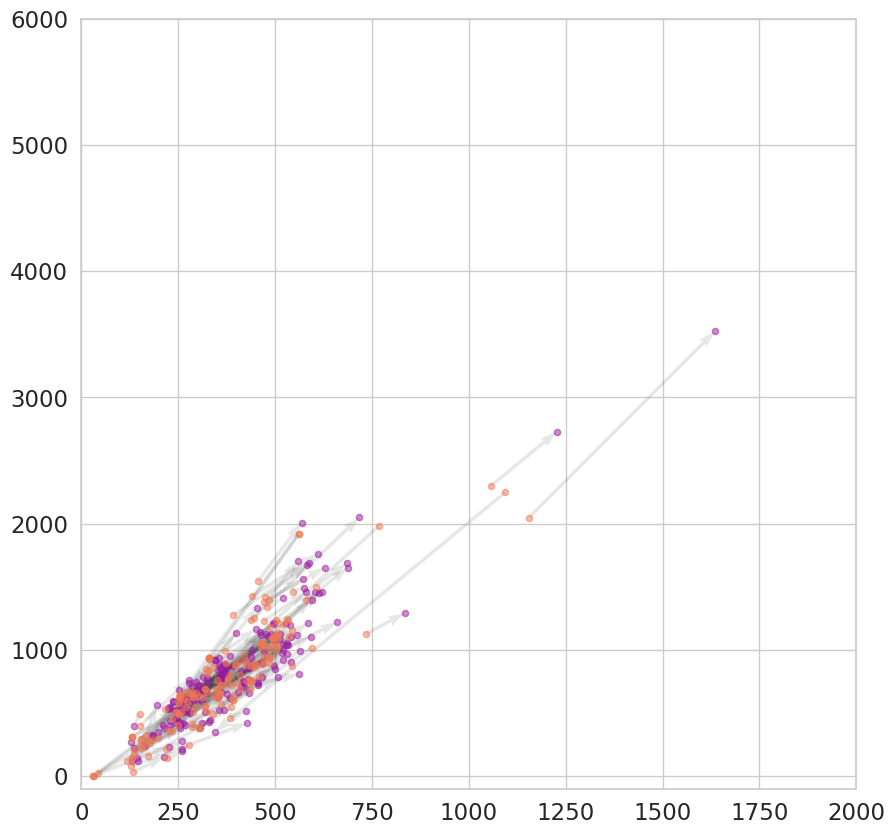

In [ ]:
# Plot the Approved Drugs

fig, ax = plt.subplots()
ax.scatter(FDA['MolWt_API'], FDA['BertzCT_API'], c = '#ed7953', marker = 'o', s = 20, zorder = 3, alpha = 0.5)
ax.scatter(FDA['MolWt_pro'], FDA['BertzCT_pro'], c = '#9c179e', marker = 'o', s = 20, zorder = 2, alpha = 0.5)

ax.quiver(FDA['MolWt_API'], FDA['BertzCT_API'], (FDA['MolWt_pro']-FDA['MolWt_API']), (FDA['BertzCT_pro']-FDA['BertzCT_API']), angles='xy', scale_units='xy', scale=1, alpha = 0.1)

plt.xlim([0, 2000])
plt.ylim([-100, 6000])

plt.savefig('Approved_PCA.svg')

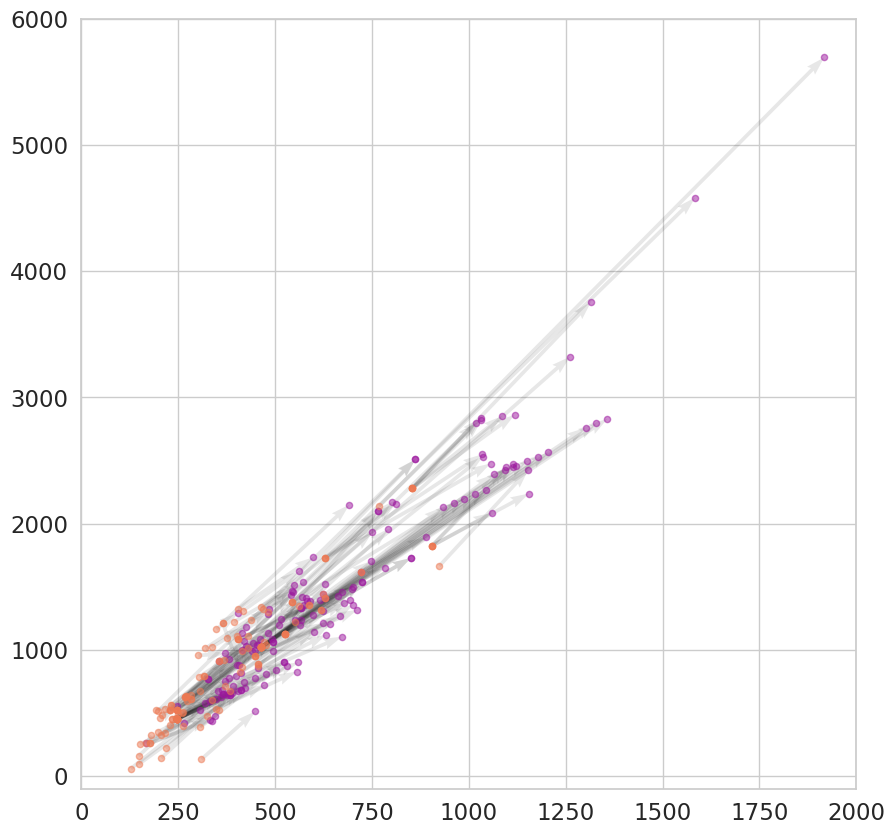

In [ ]:
# Plot the Investigational Drugs

fig, ax = plt.subplots()
ax.scatter(Investigational['MolWt_API'], Investigational['BertzCT_API'], c = '#ed7953', marker = 'o', s = 20, zorder = 3, alpha = 0.5)
ax.scatter(Investigational['MolWt_pro'], Investigational['BertzCT_pro'], c = '#9c179e', marker = 'o', s = 20, zorder = 2, alpha = 0.5)

ax.quiver(Investigational['MolWt_API'], Investigational['BertzCT_API'], (Investigational['MolWt_pro']-Investigational['MolWt_API']), (Investigational['BertzCT_pro']-Investigational['BertzCT_API']), angles='xy', scale_units='xy', scale=1, alpha = 0.1)

plt.xlim([0, 2000])
plt.ylim([-100, 6000])

plt.savefig('Investigational_PCA.svg')

# **Similarity of Prodrugs to APIs**

In [ ]:
# Load your files as dataframes
approved = pd.read_csv('FDAApprovedProdrugsAndAPIs.csv')
approved = approved[['Prodrug_SMILES','API_SMILES']]
investigational = pd.read_csv('InvestigationalProdrugAPIStructures.csv')

## Approved Prodrugs ##

# generate Morgan Fingerprints and save the results into an array for Prodrug
Pro = [Chem.MolFromSmiles(s) for s in approved['Prodrug_SMILES']]
Pro_fps_list = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024) for m in Pro]

# generate Morgan Fingerprints and save the results into an array for API
API = [Chem.MolFromSmiles(s) for s in approved['API_SMILES']]
API_fps_list = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024) for m in API]

#calculate similarities
similarity_list = []
for i in range(len(API_fps_list)):
  similarity_list.append(DataStructs.TanimotoSimilarity(API_fps_list[i], Pro_fps_list[i]))
approved_similarity = pd.DataFrame (similarity_list, columns = ['Similarity'])

## Investigational Prodrugs ##

# generate Morgan Fingerprints and save the results into an array for Prodrug
Pro = [Chem.MolFromSmiles(s) for s in investigational['Prodrug_SMILES']]
Pro_fps_list = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024) for m in Pro]

# generate Morgan Fingerprints and save the results into an array for API
API = [Chem.MolFromSmiles(s) for s in investigational['API_SMILES']]
API_fps_list = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024) for m in API]

similarity_list = []
for i in range(len(API_fps_list)):
  similarity_list.append(DataStructs.TanimotoSimilarity(API_fps_list[i], Pro_fps_list[i]))
investigational_similarity = pd.DataFrame (similarity_list, columns = ['Similarity'])

# Combine data together into appropriate format
approved_similarity['Type'] = 'Approved'
investigational_similarity['Type'] = 'Investigational'
df = pd.concat([approved_similarity, investigational_similarity])
df['X'] = 'Yes'

<ipython-input-5-b21503605d00>:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


(0.0, 1.0)

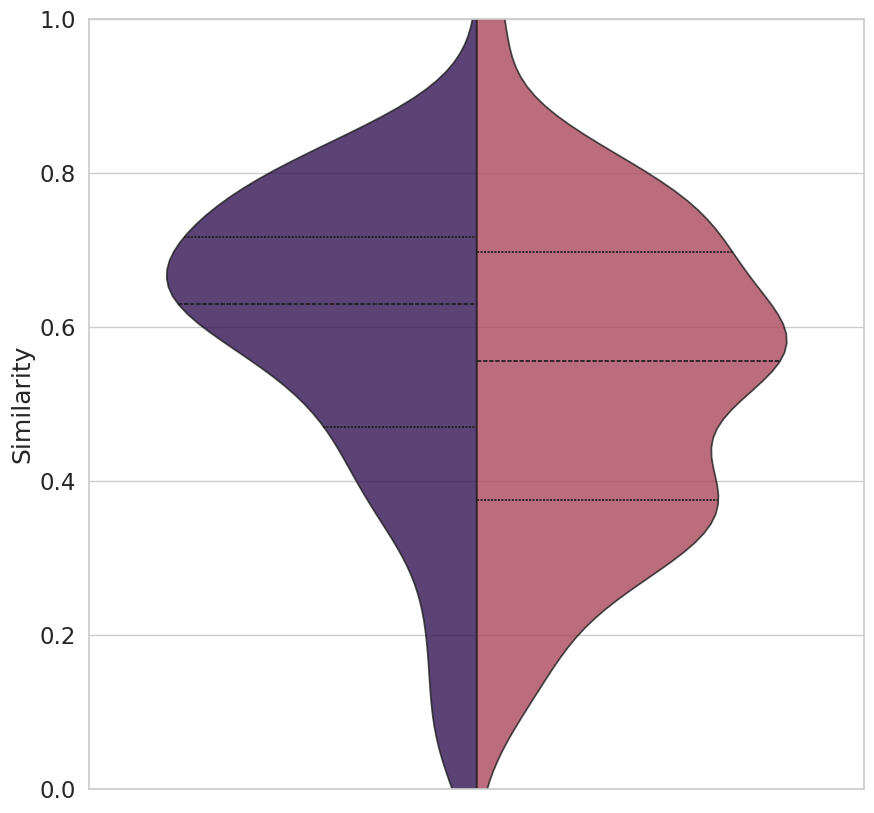

In [5]:
ax = plt.gca()
my_pallette = {"Approved": "#320a5e", "Investigational": "#bc3754"}
sns.violinplot(data=df, x="X", y="Similarity", hue="Type", palette=my_pallette, split=True, legend=False, alpha = 0.8, inner="quart")
ax.legend().set_visible(False)
ax.get_xaxis().set_visible(False)
plt.ylim(0, 1)
plt.savefig("ApprovedVsInvestigationalPromoieties.png", dpi = 300)
files.download("ApprovedVsInvestigationalPromoieties.png")